In [1]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [ ]:
from tensorflow.keras import layers, models

# 1) 读取数据
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2) 归一化到 [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0


# 3) 最简单模型：Flatten + 单层全连接（10类）
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    
    # 隐藏层
    layers.Dense(100, activation="relu"),
    
    # 输出层
    layers.Dense(10, activation="softmax")
])

# 4) 编译
model.compile(
    optimizer="sgd",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 5) 训练
model.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.1)

# 6) 测试
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", test_acc)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step - accuracy: 0.5522 - loss: 1.6779 - val_accuracy: 0.8770 - val_loss: 0.6517
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 661us/step - accuracy: 0.8490 - loss: 0.6459 - val_accuracy: 0.9000 - val_loss: 0.4333
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step - accuracy: 0.8757 - loss: 0.4800 - val_accuracy: 0.9112 - val_loss: 0.3620
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step - accuracy: 0.8869 - loss: 0.4236 - val_accuracy: 0.9140 - val_loss: 0.3262
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step - accuracy: 0.8938 - loss: 0.3881 - val_accuracy: 0.9177 - val_loss: 0.3030
Test accuracy: 0.9056000113487244


In [19]:
import numpy as np
from numpy.linalg import solve
from tensorflow.keras import layers, models
from strong_rank_revealing import strong_rrqr

def prune_1hidden_by_id_rrqr(model, x_unlabeled, keep_ratio=0.7, f=2.0, n_prune=5000):
    """
    对: Flatten -> Dense(m, relu) -> Dense(10, softmax)
    按论文思路：在无标签数据上构造 Z=g(W^T X)，对 Z^T 做 ID（用 RRQR 实现）
    返回：pruned_model, I, T
    """
    # ------- 取权重 -------
    W1, b1 = model.layers[1].get_weights()   # (784, m), (m,)
    W2, b2 = model.layers[2].get_weights()   # (m, 10), (10,)
    d, m = W1.shape
    c = W2.shape[1]

    # ------- 选 k -------
    k = int(m * keep_ratio)
    k = max(1, min(k, m-1))

    # ------- 准备 pruning 数据 X ∈ R^{d×n} -------
    X = x_unlabeled[:n_prune].reshape(n_prune, -1).T  # (784, n)

    # ------- bias 吸收进 W：增广 -------
    W1_aug = np.vstack([W1, b1.reshape(1, -1)])                 # (785, m)
    X_aug  = np.vstack([X, np.ones((1, X.shape[1]))])           # (785, n)

    # ------- 计算 Z = relu(W^T X) -------
    Z = np.maximum(W1_aug.T @ X_aug, 0.0)   # (m, n)

    # ------- 对 Z^T 做 ID：M=Z^T ∈ R^{n×m} -------
    M = Z.T

    # RRQR: M @ Pi = Q @ R
    _, R, Pi = strong_rrqr(M, k, f=f)

    # Pi -> perm（列置换顺序），I 是前 k 个代表列（保留的神经元）
    perm = np.argmax(Pi, axis=0)   # length m
    I = perm[:k]

    # 构造插值矩阵：T_hat = [I, R11^{-1}R12] (在置换后的列顺序下)
    R11 = R[:k, :k]
    R12 = R[:k, k:]
    T_hat = np.hstack([np.eye(k), solve(R11, R12)])   # (k, m)

    # 转回原列顺序：T = T_hat @ Pi^T  (k×m)
    T = T_hat @ Pi.T

    # ------- 生成剪枝后的参数 -------
    # 选子网络第一层：W_hat = W_{:,I}
    W1_hat = W1[:, I]          # (784, k)
    b1_hat = b1[I]             # (k,)

    # 第二层更新：U_hat = T U
    W2_hat = T @ W2            # (k, 10)
    b2_hat = b2.copy()         # (10,)

    # ------- 构造剪枝后的模型 -------
    pruned = models.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(k, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    pruned.build((None, 28, 28))
    pruned.layers[1].set_weights([W1_hat, b1_hat])
    pruned.layers[2].set_weights([W2_hat, b2_hat])

    return pruned, I, T


# 用训练集当作 unlabeled pruning data（不需要 y）
pruned_model, I, T = prune_1hidden_by_id_rrqr(
    model,
    x_unlabeled=x_train,
    keep_ratio=0.7,
    f=2.0,
    n_prune=5000
)

# 编译并评估（可先不微调）
pruned_model.compile(
    optimizer="sgd",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Original test:")
print(model.evaluate(x_test, y_test, verbose=0))

print("Pruned test (no finetune):")
print(pruned_model.evaluate(x_test, y_test, verbose=0))

Original test:
[0.34515172243118286, 0.9056000113487244]
Pruned test (no finetune):
[0.3498174548149109, 0.9041000008583069]


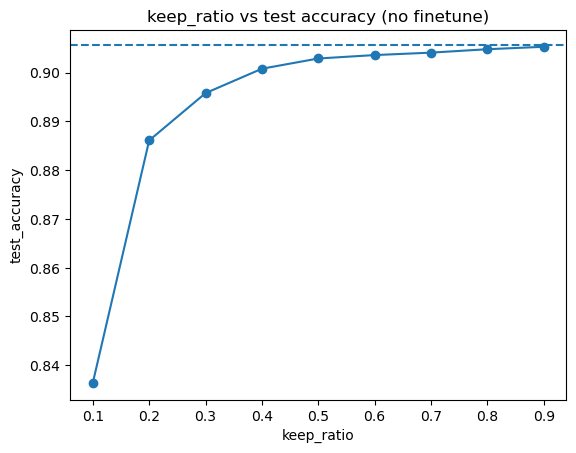

In [32]:
import matplotlib.pyplot as plt

# baseline accuracy
base_loss, base_acc = model.evaluate(x_test, y_test, verbose=0)

ratios = np.linspace(0.1, 0.9, 9)
accs = []

for r in ratios:
    pruned_model, I, T = prune_1hidden_by_id_rrqr(
        model,
        x_unlabeled=x_train,
        keep_ratio=float(r),
        f=2.0,
        n_prune=5000
    )

    pruned_model.compile(
        optimizer="sgd",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    loss, acc = pruned_model.evaluate(x_test, y_test, verbose=0)
    accs.append(acc)

plt.figure()
plt.plot(ratios, accs, marker="o")
plt.axhline(base_acc, linestyle="--")
plt.xlabel("keep_ratio")
plt.ylabel("test_accuracy")
plt.title("keep_ratio vs test accuracy (no finetune)")
plt.show()